[*********************100%***********************]  1 of 1 completed


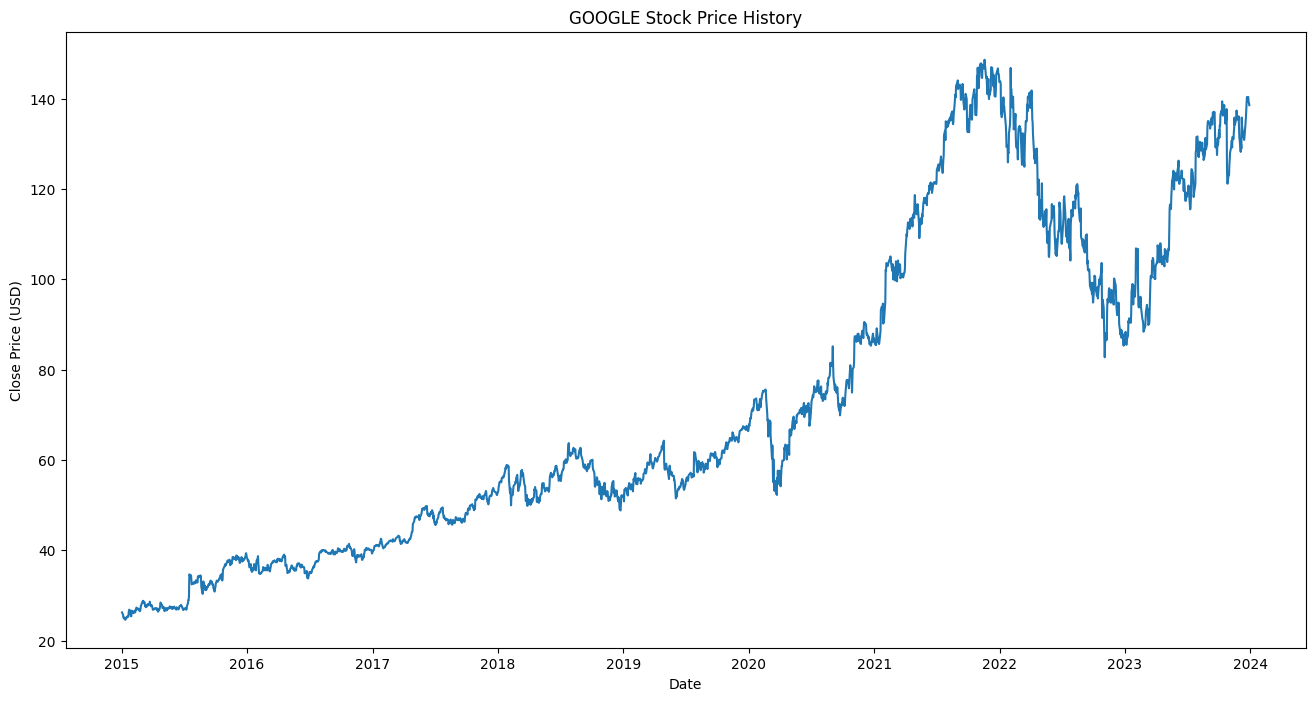

In [13]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# 2. DOWNLOAD DATA
df = yf.download("GOOGL", start="2015-01-01", end="2024-01-01")

# Use only Close price
data = df[['Close']]

# Plot stock price
plt.figure(figsize=(16,8))
plt.title("GOOGLE Stock Price History")
plt.plot(data['Close'])
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.show()

In [14]:
# 3. PREPROCESS DATA
dataset = data.values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

training_data_len = int(len(dataset) * 0.8)

train_data = scaled_data[:training_data_len]

# 4. CREATE SEQUENCES
time_steps = 30

x_train = []
y_train = []

for i in range(time_steps, len(train_data)):
    x_train.append(train_data[i-time_steps:i, 0])
    y_train.append(train_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)

# 5. BUILD MODEL
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(50),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


/Users/avartanathlay/my_jupyter_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# 6. TRAIN MODEL
model.fit(x_train, y_train, epochs=5, batch_size=32)

# 7. CREATE TEST DATA
test_data = scaled_data[training_data_len - time_steps:]

x_test = []
y_test = dataset[training_data_len:]

for i in range(time_steps, len(test_data)):
    x_test.append(test_data[i-time_steps:i, 0])

x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# 8. PREDICTIONS
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0175
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5056e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2295e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1254e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2724e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


RMSE: 5.124543633699187


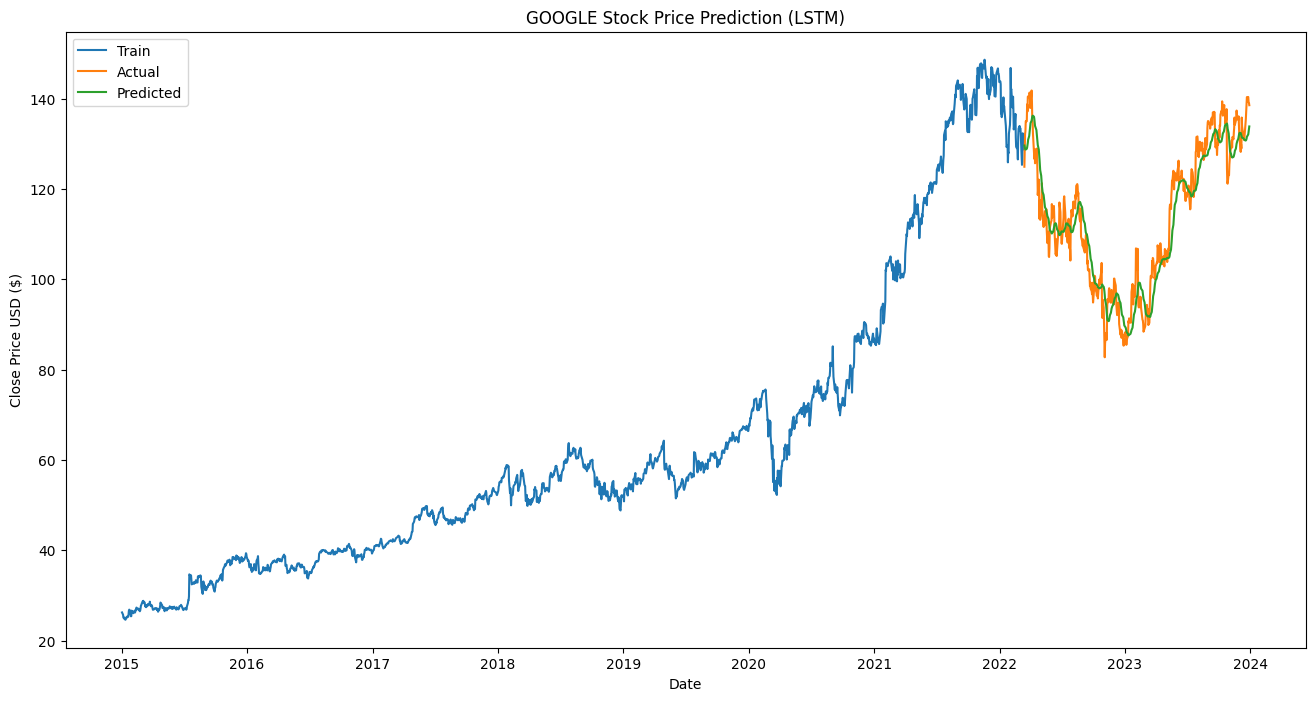

In [16]:
# 9. RMSE
rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
print("RMSE:", rmse)

# 10. PLOT RESULTS
train = data[:training_data_len]
valid = data[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title("GOOGLE Stock Price Prediction (LSTM)")
plt.xlabel("Date")
plt.ylabel("Close Price USD ($)")

plt.plot(train['Close'])
plt.plot(valid['Close'])
plt.plot(valid['Predictions'])

plt.legend(['Train', 'Actual', 'Predicted'])
plt.show()